# Explore here

In [3]:
# PASO 1: CARGA DEL CONJUNTO DE DATOS 

import pandas as pd
import numpy as np

url = "https://storage.googleapis.com/breathecode/project-files/bank-marketing-campaign-data.csv"
df = pd.read_csv(url, sep=';')

# Primeras 5 filas
print("📋 Primeras 5 filas del dataset:")
print(df.head())

print("\n" + "="*60)

# Dimensiones
print(f"\n📐 Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")

print("\n" + "="*60)

# Info general
print("\n🔍 Información general del dataset:")
print(df.info())

print("\n" + "="*60)

# Estadísticas descriptivas
print("\n📊 Estadísticas descriptivas:")
print(df.describe())

print("\n" + "="*60)

# Valores nulos
print("\n❓ Valores nulos por columna:")
print(df.isnull().sum())

print("\n" + "="*60)

# Variable objetivo
print("\n🎯 Distribución de la variable objetivo 'y':")
print(df['y'].value_counts())
print(f"\nPorcentaje:\n{df['y'].value_counts(normalize=True) * 100}")

📋 Primeras 5 filas del dataset:
   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   cons.price.idx  cons.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# Estilo general de los gráficos
plt.rcParams['figure.figsize'] = (12, 5)

In [5]:
# Separamos columnas numéricas y categóricas
numericas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categoricas = df.select_dtypes(include=['object']).columns.tolist()

print("🔢 Variables NUMÉRICAS:")
print(numericas)

print("\n🔤 Variables CATEGÓRICAS:")
print(categoricas)

🔢 Variables NUMÉRICAS:
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

🔤 Variables CATEGÓRICAS:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']


/tmp/ipykernel_1075/1174022015.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas = df.select_dtypes(include=['object']).columns.tolist()


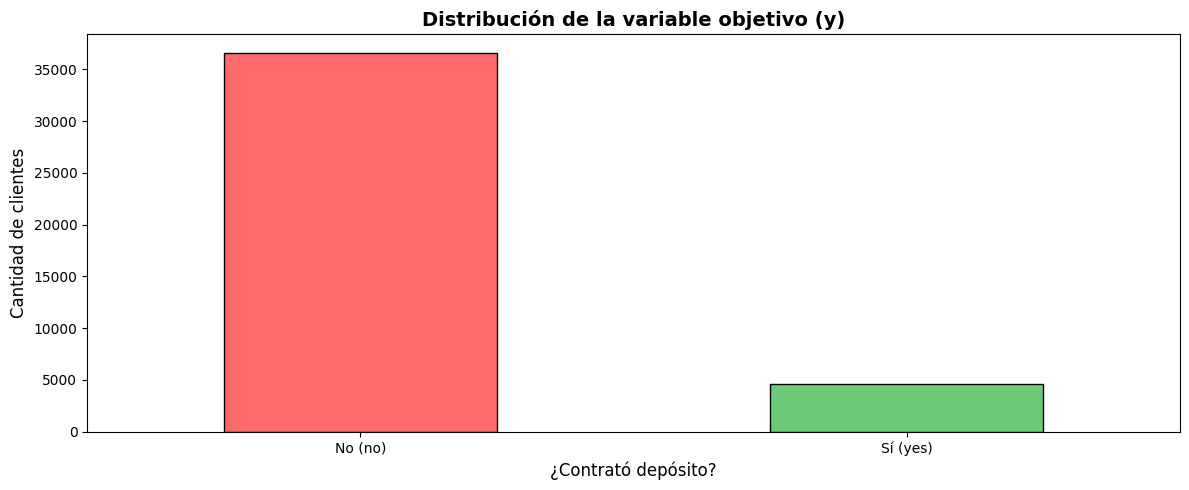


📊 Porcentaje:
y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64


In [6]:
colores_objetivo = ['#FF6B6B', '#6BCB77']

df['y'].value_counts().plot(
    kind='bar',
    color=colores_objetivo,
    edgecolor='black',
    width=0.5
)

plt.title('Distribución de la variable objetivo (y)', fontsize=14, fontweight='bold')
plt.xlabel('¿Contrató depósito?', fontsize=12)
plt.ylabel('Cantidad de clientes', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['No (no)', 'Sí (yes)'], rotation=0)
plt.tight_layout()
plt.show()

print(f"\n📊 Porcentaje:")
print(df['y'].value_counts(normalize=True) * 100)

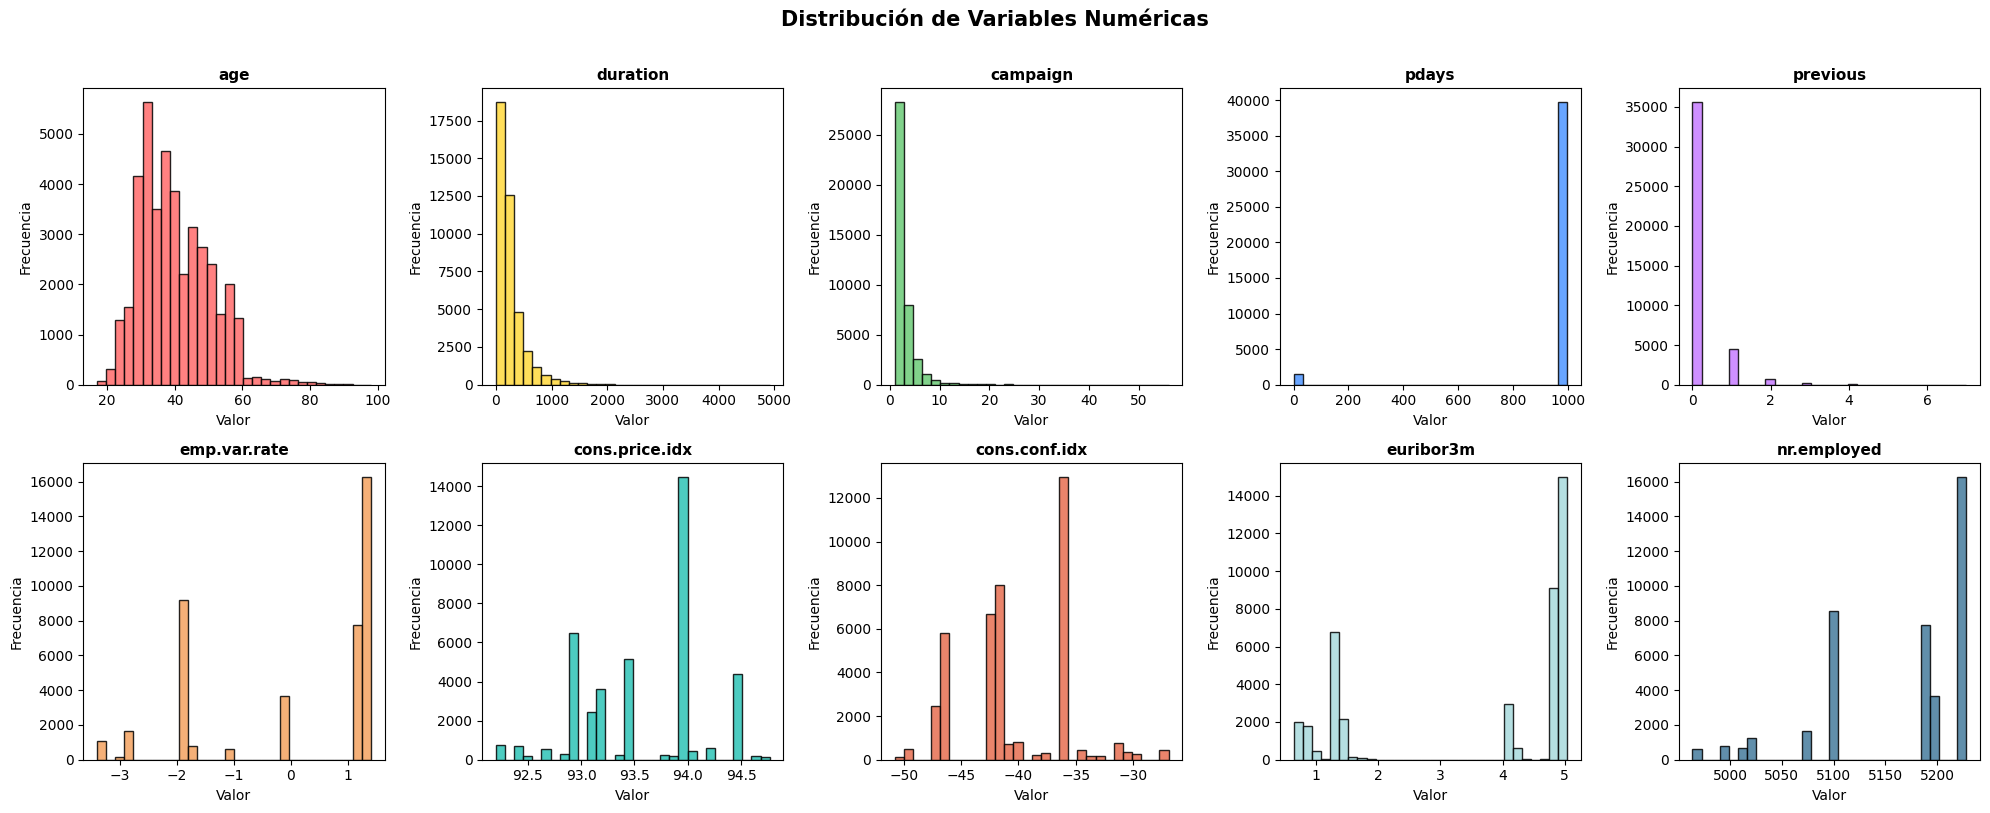

In [7]:
colores_num = ['#FF6B6B','#FFD93D','#6BCB77','#4D96FF','#C77DFF',
               '#F4A261','#2EC4B6','#E76F51','#A8DADC','#457B9D']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(numericas):
    axes[i].hist(df[col], bins=30, color=colores_num[i], edgecolor='black', alpha=0.85)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribución de Variables Numéricas', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

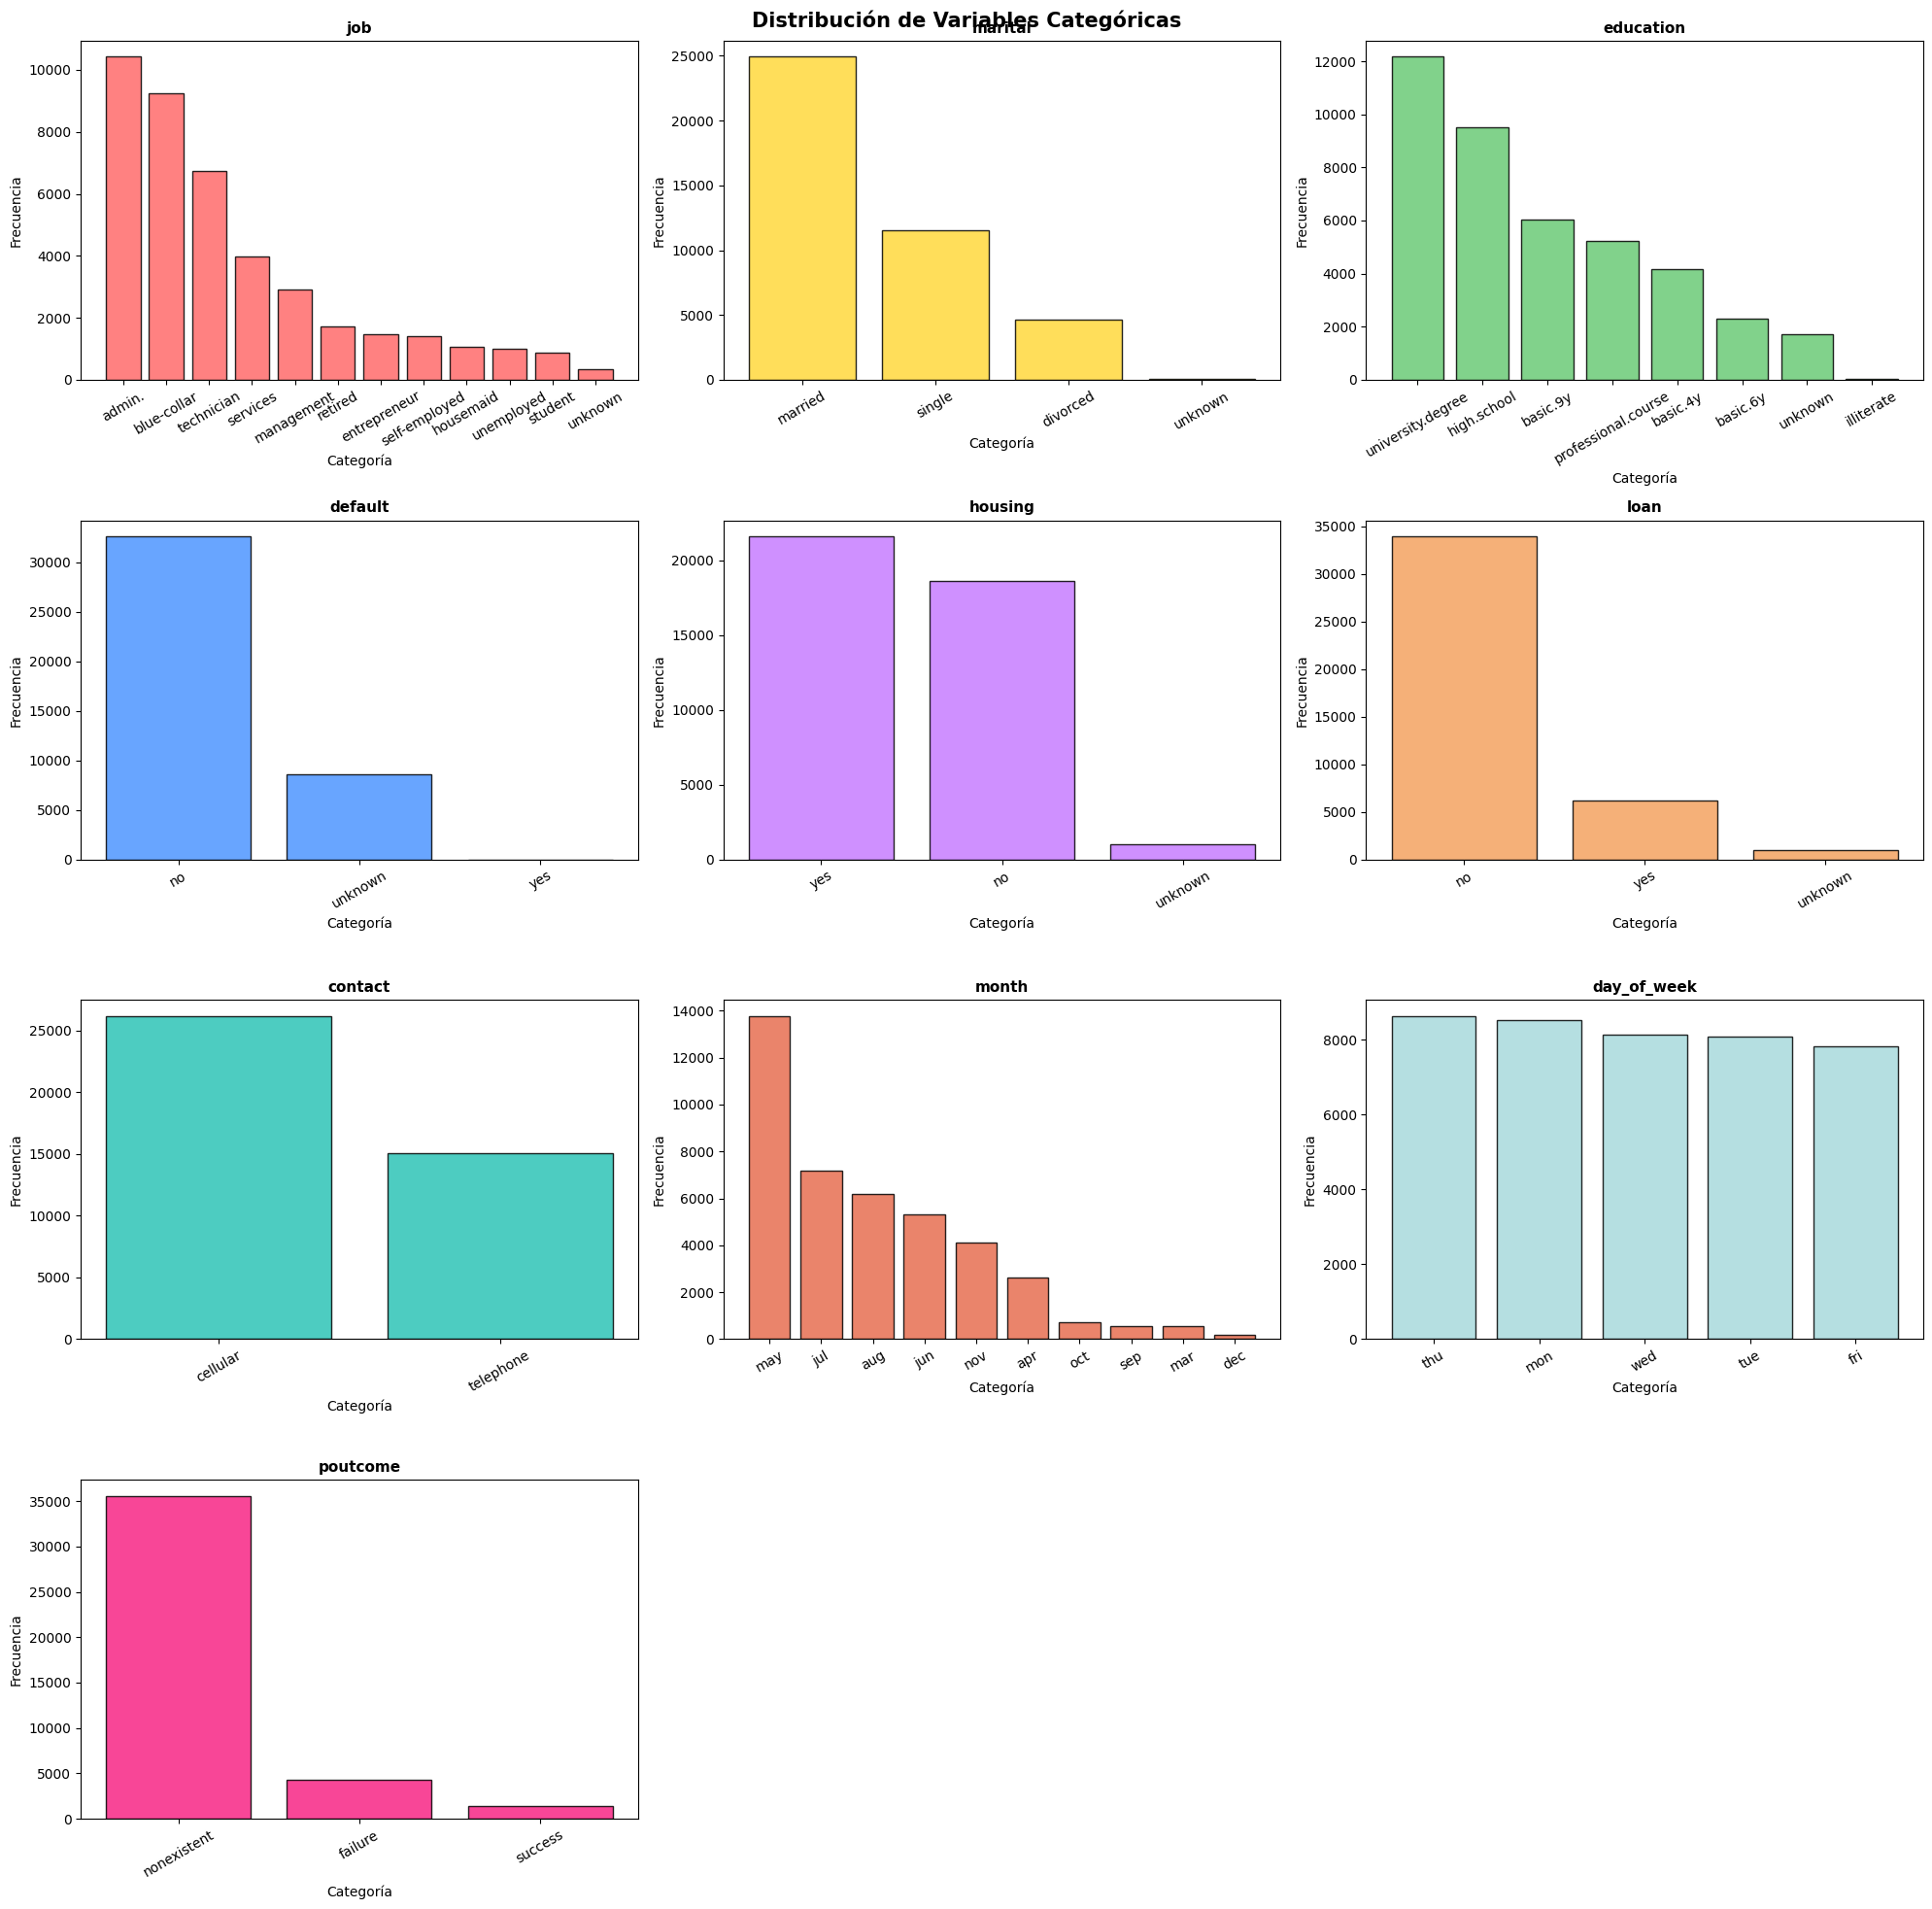

In [10]:
colores_cat = ['#FF6B6B','#FFD93D','#6BCB77','#4D96FF','#C77DFF',
               '#F4A261','#2EC4B6','#E76F51','#A8DADC','#F72585']

# Lista manual de columnas categóricas (sin 'y')
cols_cat = ['job', 'marital', 'education', 'default', 'housing',
            'loan', 'contact', 'month', 'day_of_week', 'poutcome']

# Grid de 4 filas x 3 columnas = 12 espacios 
fig, axes = plt.subplots(4, 3, figsize=(20, 20))
axes = axes.flatten()

for i, col in enumerate(cols_cat):
    conteo = df[col].value_counts()
    axes[i].bar(conteo.index, conteo.values, color=colores_cat[i], edgecolor='black', alpha=0.85)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Categoría')
    axes[i].set_ylabel('Frecuencia')
    axes[i].tick_params(axis='x', rotation=30)

axes[10].set_visible(False)
axes[11].set_visible(False)

plt.suptitle('Distribución de Variables Categóricas', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

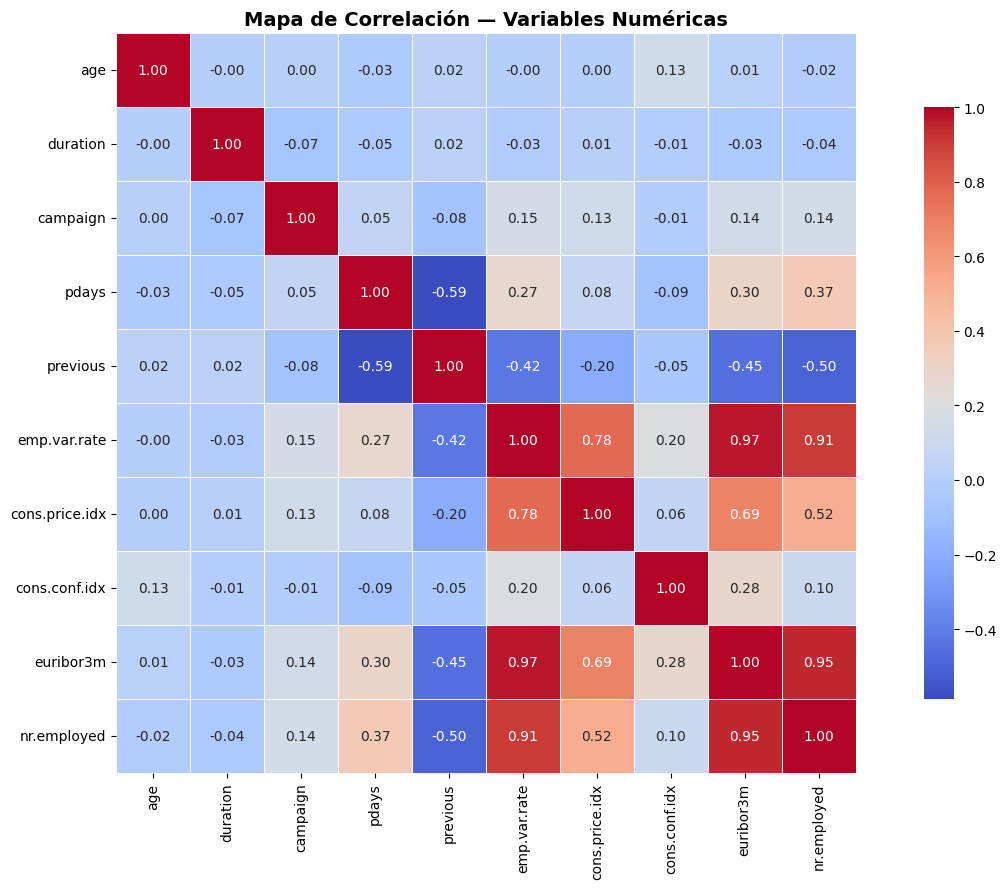

In [11]:
plt.figure(figsize=(14, 9))

correlacion = df[numericas].corr()

sns.heatmap(
    correlacion,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    linecolor='white',
    square=True,
    cbar_kws={'shrink': 0.8}
)

plt.title('Mapa de Correlación — Variables Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [27]:
if 'duration' in df.columns:
    df = df.drop(columns=['duration'])
    print("✅ Columna 'duration' eliminada")
else:
    print("⚠️ La columna 'duration' ya había sido eliminada antes, continuamos...")

print(f"📐 Shape actual: {df.shape}")

# Codificamos todas las variables categóricas con LabelEncoder
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_encoded = df.copy()

for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

print("\n✅ Variables categóricas codificadas")
print(df_encoded.head())

⚠️ La columna 'duration' ya había sido eliminada antes, continuamos...
📐 Shape actual: (41188, 20)

✅ Variables categóricas codificadas
   age  job  marital  education  default  housing  loan  contact  month  \
0   56    3        1          0        0        0     0        1      6   
1   57    7        1          3        1        0     0        1      6   
2   37    7        1          3        0        2     0        1      6   
3   40    0        1          1        0        0     0        1      6   
4   56    7        1          3        0        0     2        1      6   

   day_of_week  campaign  pdays  previous  poutcome  emp.var.rate  \
0            1         1    999         0         1           1.1   
1            1         1    999         0         1           1.1   
2            1         1    999         0         1           1.1   
3            1         1    999         0         1           1.1   
4            1         1    999         0         1           1.1   

/tmp/ipykernel_1075/1155448536.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_encoded.select_dtypes(include='object').columns:


In [28]:
from sklearn.model_selection import train_test_split

# Separamos features (X) y target (y)
X = df_encoded.drop(columns=['y'])
y = df_encoded['y']

# División 80% train / 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  
)

print(f"✅ División completada:")
print(f"   🟦 X_train: {X_train.shape}")
print(f"   🟩 X_test:  {X_test.shape}")
print(f"\n🎯 Proporción de clases en train:")
print(y_train.value_counts(normalize=True) * 100)

✅ División completada:
   🟦 X_train: (32950, 19)
   🟩 X_test:  (8238, 19)

🎯 Proporción de clases en train:
y
0    88.734446
1    11.265554
Name: proportion, dtype: float64


In [ ]:
# paso 3 regresion logistica, importar librerias.
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, 
                             classification_report, ConfusionMatrixDisplay)

In [15]:
# Creamos el modelo con configuración por defecto
modelo = LogisticRegression(max_iter=1000, random_state=42)

# Entrenamos con los datos de train
modelo.fit(X_train, y_train)

print("✅ Modelo entrenado correctamente")

✅ Modelo entrenado correctamente


/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [16]:
# Predecimos con los datos de test
y_pred = modelo.predict(X_test)

print("✅ Predicciones realizadas")
print(f"\n🔢 Primeras 10 predicciones: {y_pred[:10]}")
print(f"🎯 Valores reales:           {y_test.values[:10]}")

✅ Predicciones realizadas

🔢 Primeras 10 predicciones: [0 0 0 0 0 0 0 0 1 0]
🎯 Valores reales:           [0 0 0 0 0 0 0 0 1 0]


In [17]:
# Accuracy 
accuracy = accuracy_score(y_test, y_pred)
print(f"🎯 Accuracy del modelo: {accuracy * 100:.2f}%")

print("\n📋 Reporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=['No contrató', 'Sí contrató']))

🎯 Accuracy del modelo: 90.13%

📋 Reporte de clasificación:
              precision    recall  f1-score   support

 No contrató       0.91      0.99      0.95      7310
 Sí contrató       0.72      0.20      0.31       928

    accuracy                           0.90      8238
   macro avg       0.82      0.60      0.63      8238
weighted avg       0.89      0.90      0.88      8238



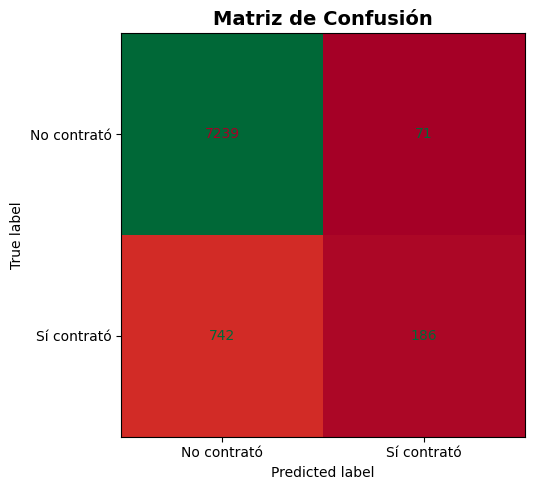


✅ Verdaderos Negativos  (dijo NO  y era NO):  7239
❌ Falsos Positivos      (dijo SÍ  y era NO):  71
❌ Falsos Negativos      (dijo NO  y era SÍ):  742
✅ Verdaderos Positivos  (dijo SÍ  y era SÍ):  186


In [18]:
fig, ax = plt.subplots(figsize=(7, 5))

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=['No contrató', 'Sí contrató'])
disp.plot(ax=ax, colorbar=False, cmap='RdYlGn')

ax.set_title('Matriz de Confusión', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\n✅ Verdaderos Negativos  (dijo NO  y era NO):  {tn}")
print(f"❌ Falsos Positivos      (dijo SÍ  y era NO):  {fp}")
print(f"❌ Falsos Negativos      (dijo NO  y era SÍ):  {fn}")
print(f"✅ Verdaderos Positivos  (dijo SÍ  y era SÍ):  {tp}")

In [19]:
# paso 4: optimizacion del modelo 
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV

In [20]:
scaler = StandardScaler()

# Entrenamos el scaler SOLO con train 
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("✅ Datos escalados correctamente")
print(f"   Media aproximada de X_train_scaled: {X_train_scaled.mean():.4f}")
print(f"   Desviación estándar de X_train_scaled: {X_train_scaled.std():.4f}")

✅ Datos escalados correctamente
   Media aproximada de X_train_scaled: 0.0000
   Desviación estándar de X_train_scaled: 1.0000


In [21]:
# Definimos los valores que queremos probar
parametros = {
    'C': [0.01, 0.1, 1, 10, 100],        # controla la regularización
    'solver': ['lbfgs', 'liblinear'],      # algoritmo de optimización
    'class_weight': [None, 'balanced']     # para manejar el desbalanceo
}

# GridSearchCV prueba TODAS las combinaciones posibles
busqueda = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    parametros,
    cv=5,           # validación cruzada con 5 particiones
    scoring='f1',   # optimizamos por F1 
    n_jobs=-1       # usa todos los núcleos del procesador
)

busqueda.fit(X_train_scaled, y_train)

print("✅ Búsqueda completada")
print(f"\n🏆 Mejores parámetros encontrados:")
print(busqueda.best_params_)
print(f"\n📊 Mejor F1-score en validación: {busqueda.best_score_:.4f}")

✅ Búsqueda completada

🏆 Mejores parámetros encontrados:
{'C': 100, 'class_weight': 'balanced', 'solver': 'liblinear'}

📊 Mejor F1-score en validación: 0.4278


In [22]:
# Usamos directamente el mejor modelo que encontró GridSearchCV
mejor_modelo = busqueda.best_estimator_

# Predicciones con el modelo optimizado
y_pred_opt = mejor_modelo.predict(X_test_scaled)

print("✅ Modelo optimizado listo")

✅ Modelo optimizado listo


In [23]:
# Métricas del modelo ORIGINAL (paso 3)
acc_original = accuracy_score(y_test, y_pred)

# Métricas del modelo OPTIMIZADO
acc_optimizado = accuracy_score(y_test, y_pred_opt)

print("="*50)
print("📊 COMPARACIÓN DE MODELOS")
print("="*50)
print(f"🔵 Accuracy modelo original:   {acc_original  * 100:.2f}%")
print(f"🟢 Accuracy modelo optimizado: {acc_optimizado * 100:.2f}%")
print("="*50)

print("\n📋 Reporte modelo OPTIMIZADO:")
print(classification_report(y_test, y_pred_opt, target_names=['No contrató', 'Sí contrató']))

📊 COMPARACIÓN DE MODELOS
🔵 Accuracy modelo original:   90.13%
🟢 Accuracy modelo optimizado: 81.31%

📋 Reporte modelo OPTIMIZADO:
              precision    recall  f1-score   support

 No contrató       0.95      0.83      0.89      7310
 Sí contrató       0.33      0.65      0.44       928

    accuracy                           0.81      8238
   macro avg       0.64      0.74      0.66      8238
weighted avg       0.88      0.81      0.84      8238



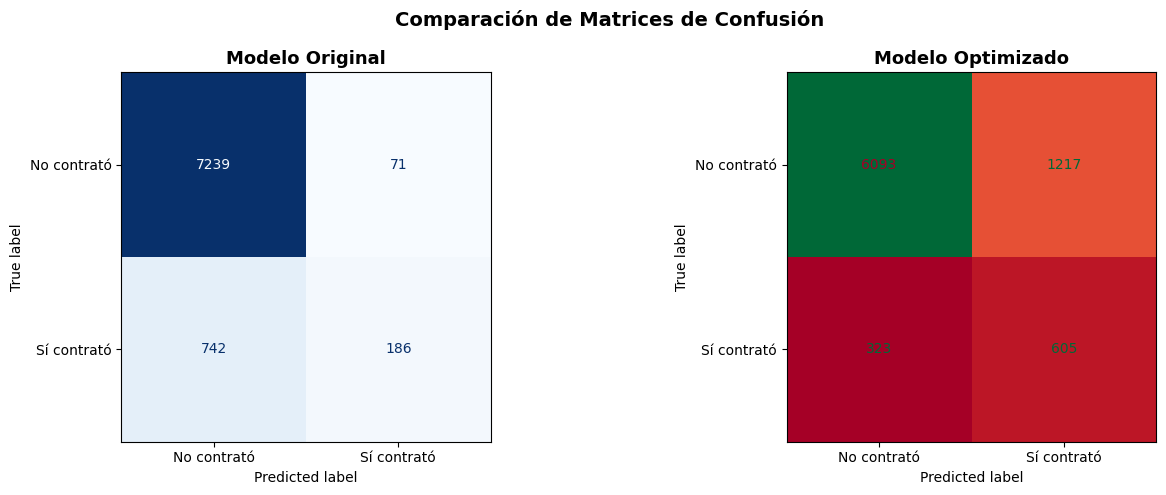

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz modelo original
cm_original = confusion_matrix(y_test, y_pred)
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_original,
                                display_labels=['No contrató', 'Sí contrató'])
disp1.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Modelo Original', fontsize=13, fontweight='bold')

# Matriz modelo optimizado
cm_opt = confusion_matrix(y_test, y_pred_opt)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_opt,
                                display_labels=['No contrató', 'Sí contrató'])
disp2.plot(ax=axes[1], colorbar=False, cmap='RdYlGn')
axes[1].set_title('Modelo Optimizado', fontsize=13, fontweight='bold')

plt.suptitle('Comparación de Matrices de Confusión', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()